Load FX dataset and basic cleaning

In [141]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("sys.path[0]:", sys.path[0])
print("fx_forecasting exists:", (PROJECT_ROOT / "fx_forecasting").exists())

PROJECT_ROOT: /Users/liuxingyu/Desktop/COMP0197-group-project
sys.path[0]: /Users/liuxingyu/Desktop/COMP0197-group-project
fx_forecasting exists: True


In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse your repo loader/cleaner (no sklearn needed here)
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import clean_fx_data, time_train_test_split

PROJECT_ROOT = Path.cwd().parents[0]  # notebook in notebooks/
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "main_with_exo_2.csv"

TARGET = "GBP-CNY"
EXOG = ["GBP-USD","GBP-EUR","GBP-JPY","GBP-KRW","GBP-CHF"]
FX_ONLY_COLS = ["timestamp", TARGET] + EXOG

TEST_RATIO = 0.2
print("DATA_PATH exists:", DATA_PATH.exists(), DATA_PATH)

DATA_PATH exists: True /Users/liuxingyu/Desktop/COMP0197-group-project/data/raw/main_with_exo_2.csv


Read CSV, select only the 6 FX series + timestamp (ignore all other columns)



In [143]:
res = load_fx_csv(DATA_PATH, date_col="Date")
print("type(res):", type(res))

if isinstance(res, (tuple, list)):
    print("len(res):", len(res))
    for i, item in enumerate(res):
        print(f"[{i}] type:", type(item))
        if hasattr(item, "head"):
            print(item.head(2))
else:
    # single object
    if hasattr(res, "head"):
        print(res.head(2))
    else:
        print("res preview:", str(res)[:200])

type(res): <class 'pandas.DataFrame'>
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF  \
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373   
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338   

   ftse100_Close  gold_price  DTWEXBGS  DGS10  DCOILBRENTEU  vix_daily_close  \
0    6547.799805      760.79  102.9027   2.12         55.38        17.790001   
1    6417.200195      788.02  103.4976   2.04         51.08        19.920000   

   glc_nominal_2  glc_nominal_10  ois_1  ois_2  
0           0.50            1.79   0.49   0.66  
1           0.48            1.73   0.48   0.62  


In [144]:
df = load_fx_csv(DATA_PATH, date_col="Date")

FX_ONLY_COLS = [
    "timestamp",
    "GBP-CNY",
    "GBP-USD",
    "GBP-EUR",
    "GBP-JPY",
    "GBP-KRW",
    "GBP-CHF",
]

# drop non-fx columns
df = df[FX_ONLY_COLS].copy()

# do basic cleaning
df = clean_fx_data(df, timestamp_col="timestamp")
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
print(df.columns.tolist())
print(df["timestamp"].min(), "→", df["timestamp"].max())
df.head()

(2779, 7)
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']
2015-01-02 00:00:00 → 2025-12-31 00:00:00


,timestamp,GBP-CNY,GBP-USD,GBP-EUR,GBP-JPY,GBP-KRW,GBP-CHF
0,2015-01-02,9.5476,1.5388,1.2790,184.9638,1702.0821,1.5373
1,2015-01-05,9.4794,1.5240,1.2767,182.2552,1690.7256,1.5338
2,2015-01-06,9.4244,1.5170,1.2727,180.0831,1670.4901,1.5287
3,2015-01-07,9.3582,1.5063,1.2762,179.9275,1661.7351,1.5327
4,2015-01-08,9.3724,1.5082,1.2789,180.5014,1654.6764,1.5363


Visualize the target series in level space (GBP-CNY) to sanity-check trends/outliers


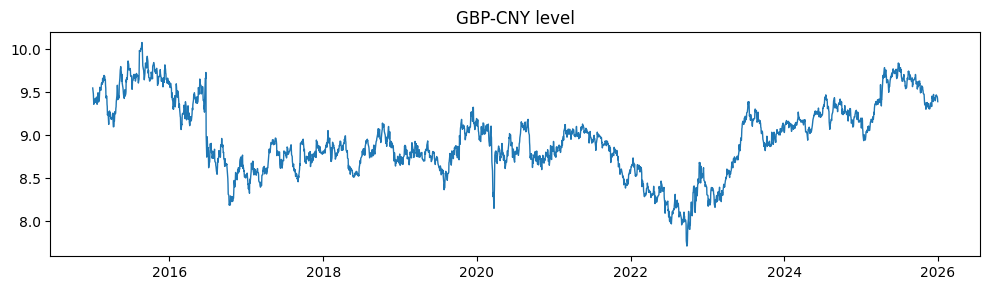

In [145]:
plt.figure(figsize=(10,3))
plt.plot(df["timestamp"], df[TARGET], linewidth=1)
plt.title(f"{TARGET} level")
plt.tight_layout()
plt.show()

Construct log returns for target and exogenous FX series (more stationary for linear baselines)

We will fit AR/ARX on returns, then reconstruct predicted levels for fair comparison with LSTM (which predicts level).

In [146]:
ret_df = df.copy()

for col in [TARGET] + EXOG:
    ret_df[col + "_ret"] = np.log(ret_df[col]).diff()

# drop first row (NaN from diff)
ret_df = ret_df.dropna().reset_index(drop=True)

ret_cols = [TARGET + "_ret"] + [c + "_ret" for c in EXOG]
ret_df[["timestamp", TARGET] + ret_cols].head()

,timestamp,GBP-CNY,GBP-CNY_ret,GBP-USD_ret,GBP-EUR_ret,GBP-JPY_ret,GBP-KRW_ret,GBP-CHF_ret
0,2015-01-05,9.4794,-0.007169,-0.009664,-0.001800,-0.014752,-0.006694,-0.002279
1,2015-01-06,9.4244,-0.005819,-0.004604,-0.003138,-0.011989,-0.012041,-0.003331
2,2015-01-07,9.3582,-0.007049,-0.007078,0.002746,-0.000864,-0.005255,0.002613
3,2015-01-08,9.3724,0.001516,0.001261,0.002113,0.003185,-0.004257,0.002346
4,2015-01-09,9.4046,0.003430,0.004367,0.000938,-0.002425,-0.004496,0.000716


Time-based train/test split (same idea as the LSTM baseline: last 20% as test)


In [147]:
train_df, test_df = time_train_test_split(ret_df, test_ratio=TEST_RATIO)

r_train = train_df[TARGET + "_ret"].values
r_test  = test_df[TARGET + "_ret"].values

X_train_exog = train_df[[c + "_ret" for c in EXOG]].values
X_test_exog  = test_df[[c + "_ret" for c in EXOG]].values

level_test = test_df[TARGET].values

# anchor level: last training level to reconstruct test levels from predicted returns
split_idx = len(train_df)
anchor_level = ret_df[TARGET].values[split_idx - 1]

print("train rows:", len(train_df), "test rows:", len(test_df))
print("test range:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())

train rows: 2222 test rows: 556
test range: 2023-10-20 00:00:00 → 2025-12-31 00:00:00


In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


lagged design matrices + level reconstruction + metrics

In [149]:
import numpy as np

def make_ar_xy(y, p: int):
    """
    y: (T,)
    X: (T-p, p) with columns [y_{t-1},...,y_{t-p}]
    y_target: (T-p,)
    """
    T = len(y)
    X = np.zeros((T - p, p), dtype=float)
    y_target = y[p:].astype(float)
    for t in range(p, T):
        X[t - p, :] = y[t - p:t][::-1]
    return X, y_target

def make_arx_xy(y, exog, p: int, q: int = 1):
    """
    ARX(p,q):
      X = [y_{t-1..t-p}, exog_{t-1..t-q}] flatten
    exog: (T,k)
    """
    T = len(y)
    k = exog.shape[1]
    start = max(p, q)
    rows = T - start
    X = np.zeros((rows, p + q*k), dtype=float)
    y_target = y[start:].astype(float)

    for t in range(start, T):
        ar_part = y[t - p:t][::-1]                    # (p,)
        ex_part = exog[t - q:t, :].reshape(-1)        # (q*k,)
        X[t - start, :] = np.concatenate([ar_part, ex_part])
    return X, y_target

def reconstruct_levels(anchor_level, pred_rets):
    p = float(anchor_level)
    out = []
    for r in pred_rets:
        p = p * float(np.exp(r))
        out.append(p)
    return np.array(out)

def mae(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.mean(np.abs(a - b)))

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def r2(preds, targets):
    preds = np.asarray(preds).reshape(-1)
    targets = np.asarray(targets).reshape(-1)
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - np.mean(targets)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

## Bulid AR(p) model
Fit AR(p) baseline (Linear Regression on lagged target returns)

In [150]:
P = 10  # try 1,3,5,10 later

# AR: only target return lags
X_ar_train, y_ar_train = make_ar_xy(r_train, p=P)

scaler_ar = StandardScaler()
X_ar_train_z = scaler_ar.fit_transform(X_ar_train)

ar_model = Ridge(alpha=1.0)
ar_model.fit(X_ar_train_z, y_ar_train)

print("AR coef shape:", ar_model.coef_.shape)

AR coef shape: (10,)


AR 1-step rolling prediction on the test set (walk-forward)

At each step, we update the history with the true observed return, but keep coefficients fixed (fast).
(If you want the purist version: refit each step, but that’s slower; this is a common baseline.)

In [151]:
history = list(r_train)
preds_ret_ar = []

for t in range(len(r_test)):
    y_hist = np.array(history, dtype=float)

    # build next AR feature row: last P returns
    x_next = y_hist[-P:][::-1].reshape(1, -1)
    x_next_z = scaler_ar.transform(x_next)

    pred = float(ar_model.predict(x_next_z)[0])
    preds_ret_ar.append(pred)

    history.append(float(r_test[t]))  # walk-forward update with true



preds_ret_ar = np.array(preds_ret_ar)
shift_ar = test_targets_level[0] - pred_levels_ar[0]
pred_levels_ar = pred_levels_ar + shift_ar
print("AR(p) returns:  MAE =", mae(preds_ret_ar, r_test), "RMSE =", rmse(preds_ret_ar, r_test), "R2 =", r2(preds_ret_ar, r_test))
print("AR(p) levels :  MAE =", mae(pred_levels_ar, level_test), "RMSE =", rmse(pred_levels_ar, level_test), "R2 =", r2(pred_levels_ar, level_test))

AR(p) returns:  MAE = 0.0030038762965664085 RMSE = 0.004014084258128061 R2 = -0.014600383880640333
AR(p) levels :  MAE = 0.46371146882204134 RMSE = 0.5233994680577287 R2 = -3.9842492274738754


## Bulid ARX(p) model

Fit ARX(p,q) baseline (target return lags + exogenous return lags)
We use q=1 as the simplest ARX.

In [152]:
Q = 1  # exog lag

X_arx_train, y_arx_train = make_arx_xy(r_train, X_train_exog, p=P, q=Q)

scaler_arx = StandardScaler()
X_arx_train_z = scaler_arx.fit_transform(X_arx_train)

arx_model = Ridge(alpha=1.0)
arx_model.fit(X_arx_train_z, y_arx_train)

print("ARX coef shape:", arx_model.coef_.shape)

ARX coef shape: (15,)


ARX 1-step rolling prediction on test set (walk-forward)

In [153]:
history_y = list(r_train)
history_X = [row for row in X_train_exog]
preds_ret_arx = []

k = X_train_exog.shape[1]  # number of exog series

for t in range(len(r_test)):
    y_hist = np.array(history_y, dtype=float)
    X_hist = np.array(history_X, dtype=float)

    ar_part = y_hist[-P:][::-1]                 # (P,)
    ex_part = X_test_exog[t:t+1, :].reshape(-1) # (k,) since Q=1
    x_next = np.concatenate([ar_part, ex_part]).reshape(1, -1)

    x_next_z = scaler_arx.transform(x_next)
    pred = float(arx_model.predict(x_next_z)[0])
    preds_ret_arx.append(pred)

    # update with true
    history_y.append(float(r_test[t]))
    history_X.append(X_test_exog[t])

preds_ret_arx = np.array(preds_ret_arx)


shift_arx = test_targets_level[0] - pred_levels_arx[0]
pred_levels_arx = pred_levels_arx + shift_arx

print("ARX(p,q) returns: MAE =", mae(preds_ret_arx, r_test), "RMSE =", rmse(preds_ret_arx, r_test), "R2 =", r2(preds_ret_arx, r_test))
print("ARX(p,q) levels : MAE =", mae(pred_levels_arx, level_test), "RMSE =", rmse(pred_levels_arx, level_test), "R2 =", r2(pred_levels_arx, level_test))

ARX(p,q) returns: MAE = 0.0026230228055985094 RMSE = 0.0035214543691398227 R2 = 0.2191525722888118
ARX(p,q) levels : MAE = 0.4825709184404183 RMSE = 0.5757023643720712 R2 = -5.030165373260673


## Visualization 

Plot: true level vs AR / ARX reconstructed level predictions

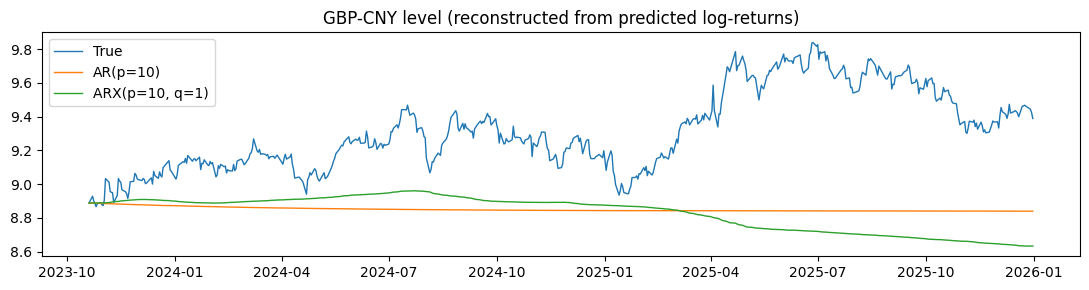

In [154]:
ts = test_df["timestamp"].values

plt.figure(figsize=(11,3))
plt.plot(ts, level_test, label="True", linewidth=1)
plt.plot(ts, pred_levels_ar, label=f"AR(p={P})", linewidth=1)
plt.plot(ts, pred_levels_arx, label=f"ARX(p={P}, q={Q})", linewidth=1)
plt.title(f"{TARGET} level (reconstructed from predicted log-returns)")
plt.legend()
plt.tight_layout()
plt.show()

## Deterministic AR / ARX outputs (aligned with LSTM evaluate_model)


In [132]:
import numpy as np
import json
from pathlib import Path

from fx_forecasting.visualization.plots import plot_predictions

def compute_metrics_lstm_style(preds, targets):
    """
    EXACTLY match fx_forecasting/training/evaluate.py -> compute_metrics keys:
    MSE, RMSE, MAE
    """
    preds = np.asarray(preds).reshape(-1)
    targets = np.asarray(targets).reshape(-1)

    mse = float(np.mean((preds - targets) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(preds - targets)))

    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

def compute_r2(preds, targets):
    preds = np.asarray(preds).reshape(-1)
    targets = np.asarray(targets).reshape(-1)
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - np.mean(targets)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

In [133]:
# Train/Test true levels for the same target as LSTM plot_predictions expects
train_targets_level = train_df[TARGET].values
test_targets_level = level_test  # or: test_df[TARGET].values

print("train_targets_level:", train_targets_level.shape)
print("test_targets_level :", np.asarray(test_targets_level).shape)
print("pred_levels_ar     :", np.asarray(pred_levels_ar).shape)
print("pred_levels_arx    :", np.asarray(pred_levels_arx).shape)

train_targets_level: (2222,)
test_targets_level : (556,)
pred_levels_ar     : (556,)
pred_levels_arx    : (556,)



[AR] Deterministic metrics (aligned with LSTM evaluate_model):
MSE: 0.273947
RMSE: 0.523399
MAE: 0.463711


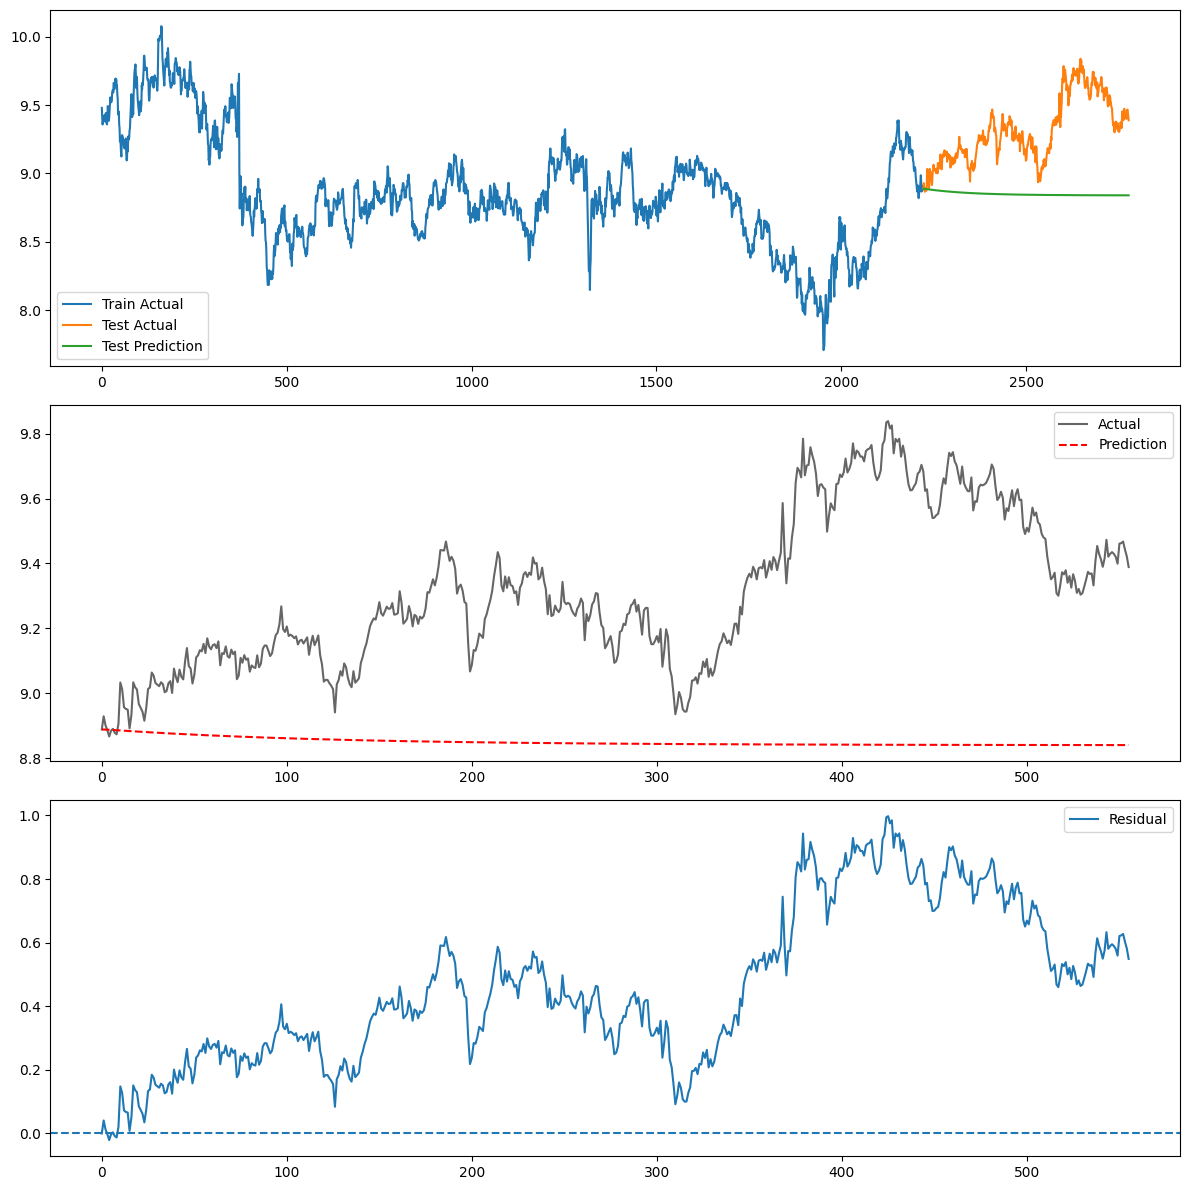


[ARX] Deterministic metrics (aligned with LSTM evaluate_model):
MSE: 0.331433
RMSE: 0.575702
MAE: 0.482571


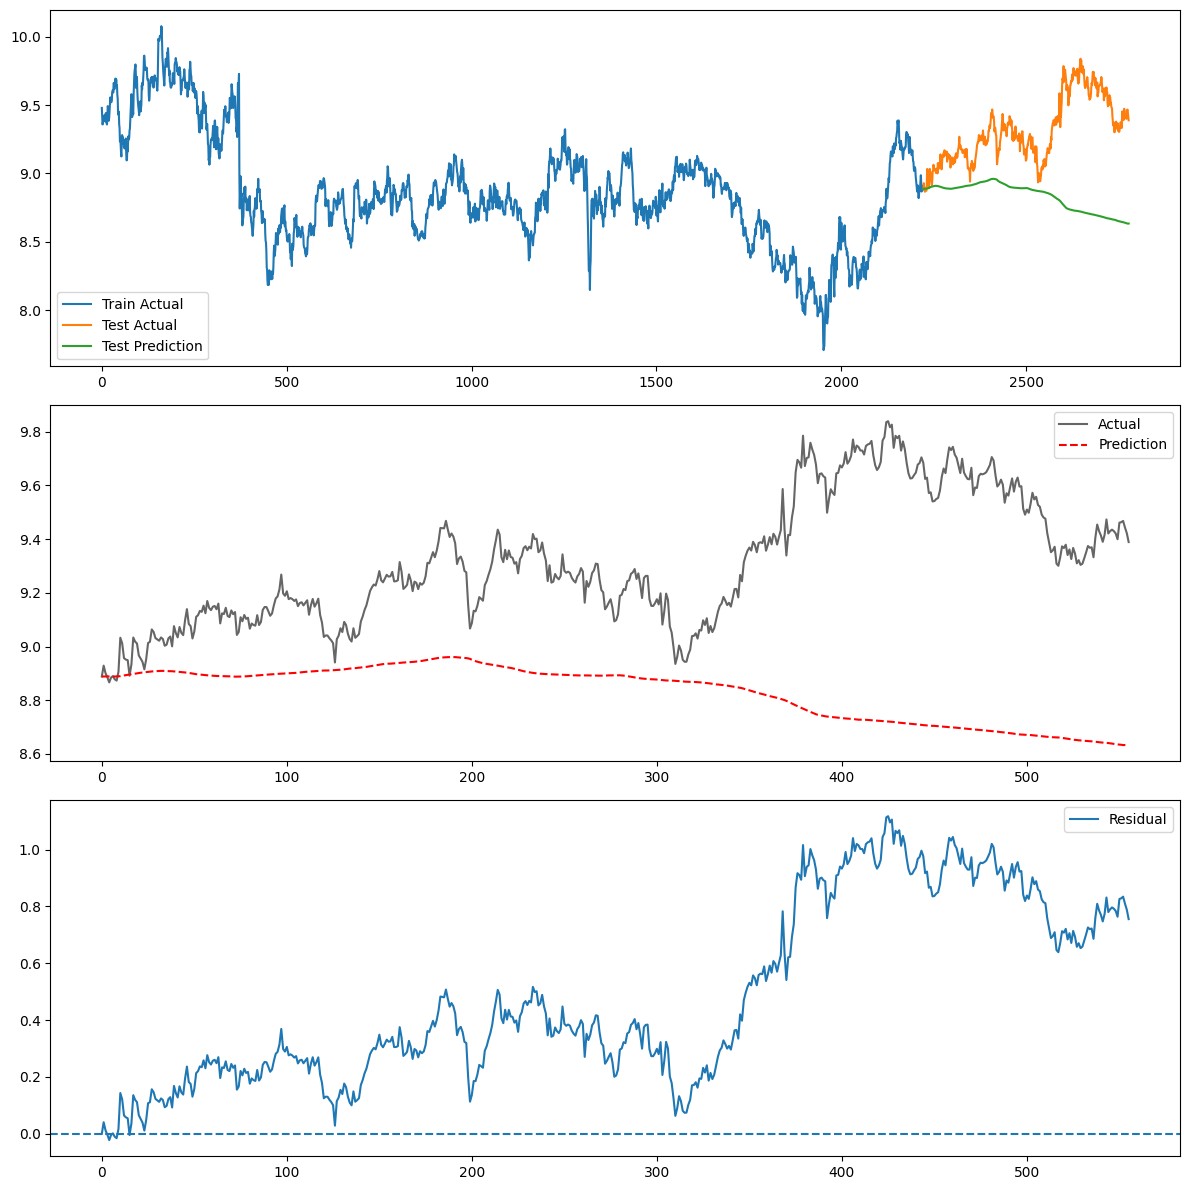


Saved: /Users/liuxingyu/Desktop/COMP0197-group-project/notebooks/outputs/metrics/ar_metrics.json
Saved: /Users/liuxingyu/Desktop/COMP0197-group-project/notebooks/outputs/metrics/arx_metrics.json


In [155]:
# ---- AR deterministic metrics + plot ----
ar_metrics = compute_metrics_lstm_style(pred_levels_ar, test_targets_level)

print("\n[AR] Deterministic metrics (aligned with LSTM evaluate_model):")
for k, v in ar_metrics.items():
    print(f"{k}: {v:.6f}")


plot_predictions(
    preds=pred_levels_ar,
    targets=test_targets_level,
    train_targets=train_targets_level
)

# ---- ARX deterministic metrics + plot ----
arx_metrics = compute_metrics_lstm_style(pred_levels_arx, test_targets_level)

print("\n[ARX] Deterministic metrics (aligned with LSTM evaluate_model):")
for k, v in arx_metrics.items():
    print(f"{k}: {v:.6f}")



plot_predictions(
    preds=pred_levels_arx,
    targets=test_targets_level,
    train_targets=train_targets_level
)

# ---- Optional: save metrics JSON to outputs/metrics (same folder style as LSTM) ----
PROJECT_ROOT = Path.cwd()  # if you already have PROJECT_ROOT in notebook, delete this line
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

with open(metrics_dir / "ar_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"model_type": "ar", **ar_metrics}, f, indent=2)

with open(metrics_dir / "arx_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"model_type": "arx", **arx_metrics}, f, indent=2)

print("\nSaved:", metrics_dir / "ar_metrics.json")
print("Saved:", metrics_dir / "arx_metrics.json")

### Level AR / ARX baseline

We fit linear AR(p) and ARX(p,q) models directly on FX levels (no return-to-level reconstruction) to avoid cumulative drift from return integration.

In [116]:
# --- Prepare LEVEL series for AR/ARX ---
y_train_level = train_df[TARGET].values.astype(float)
y_test_level  = test_df[TARGET].values.astype(float)

# exogenous: use LEVEL exog 
X_train_exog = train_df[EXOG].values.astype(float)
X_test_exog  = test_df[EXOG].values.astype(float)

print("train level len:", len(y_train_level), "test level len:", len(y_test_level))

train level len: 2222 test level len: 556


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

P = 10  

X_ar_train, y_ar_train = make_ar_xy(y_train_level, p=P)
scaler_ar = StandardScaler()
X_ar_train_z = scaler_ar.fit_transform(X_ar_train)

ar_model = Ridge(alpha=1.0)
ar_model.fit(X_ar_train_z, y_ar_train)

print("AR(level) coef shape:", ar_model.coef_.shape)

AR(level) coef shape: (5,)


In [ ]:
# --- AR(level) walk-forward prediction on TEST ---
history = list(y_train_level)   # real levels as history for AR features
pred_levels_ar = []

for t in range(len(y_test_level)):
    ar_part = np.array(history[-P:][::-1], dtype=float)
    x_row = ar_part.reshape(1, -1)
    x_row_z = scaler_ar.transform(x_row)
    y_hat = ar_model.predict(x_row_z)[0]
    pred_levels_ar.append(y_hat)

    # update history: here use true y_test_level[t] (walk-forward teacher forcing)
    history.append(y_hat)

pred_levels_ar = np.array(pred_levels_ar)

In [ ]:
Q = 1  

X_arx_train, y_arx_train = make_arx_xy(y_train_level, X_train_exog, p=P, q=Q)
scaler_arx = StandardScaler()
X_arx_train_z = scaler_arx.fit_transform(X_arx_train)

arx_model = Ridge(alpha=1.0)
arx_model.fit(X_arx_train_z, y_arx_train)

print("ARX(level) coef shape:", arx_model.coef_.shape)

ARX(level) coef shape: (10,)


In [ ]:
# --- ARX(level) walk-forward prediction on TEST ---
history_y = list(y_train_level)
history_X = list(X_train_exog)

pred_levels_arx = []

for t in range(len(y_test_level)):
    ar_part = np.array(history_y[-P:][::-1], dtype=float)

    # exog use lagged exog: take last Q rows (Q=1 -> history_X[-1])
    ex_part = np.array(history_X[-Q:], dtype=float).reshape(-1)

    x_row = np.concatenate([ar_part, ex_part]).reshape(1, -1)
    x_row_z = scaler_arx.transform(x_row)
    y_hat = arx_model.predict(x_row_z)[0]
    pred_levels_arx.append(y_hat)

    # update history: here use true y_test_level[t] and true X_test_exog[t]
    history_y.append(y_hat)
    history_X.append(X_test_exog[t])

pred_levels_arx = np.array(pred_levels_arx)


[AR(level)] Deterministic metrics:
MSE: 0.273947
RMSE: 0.523399
MAE: 0.463711


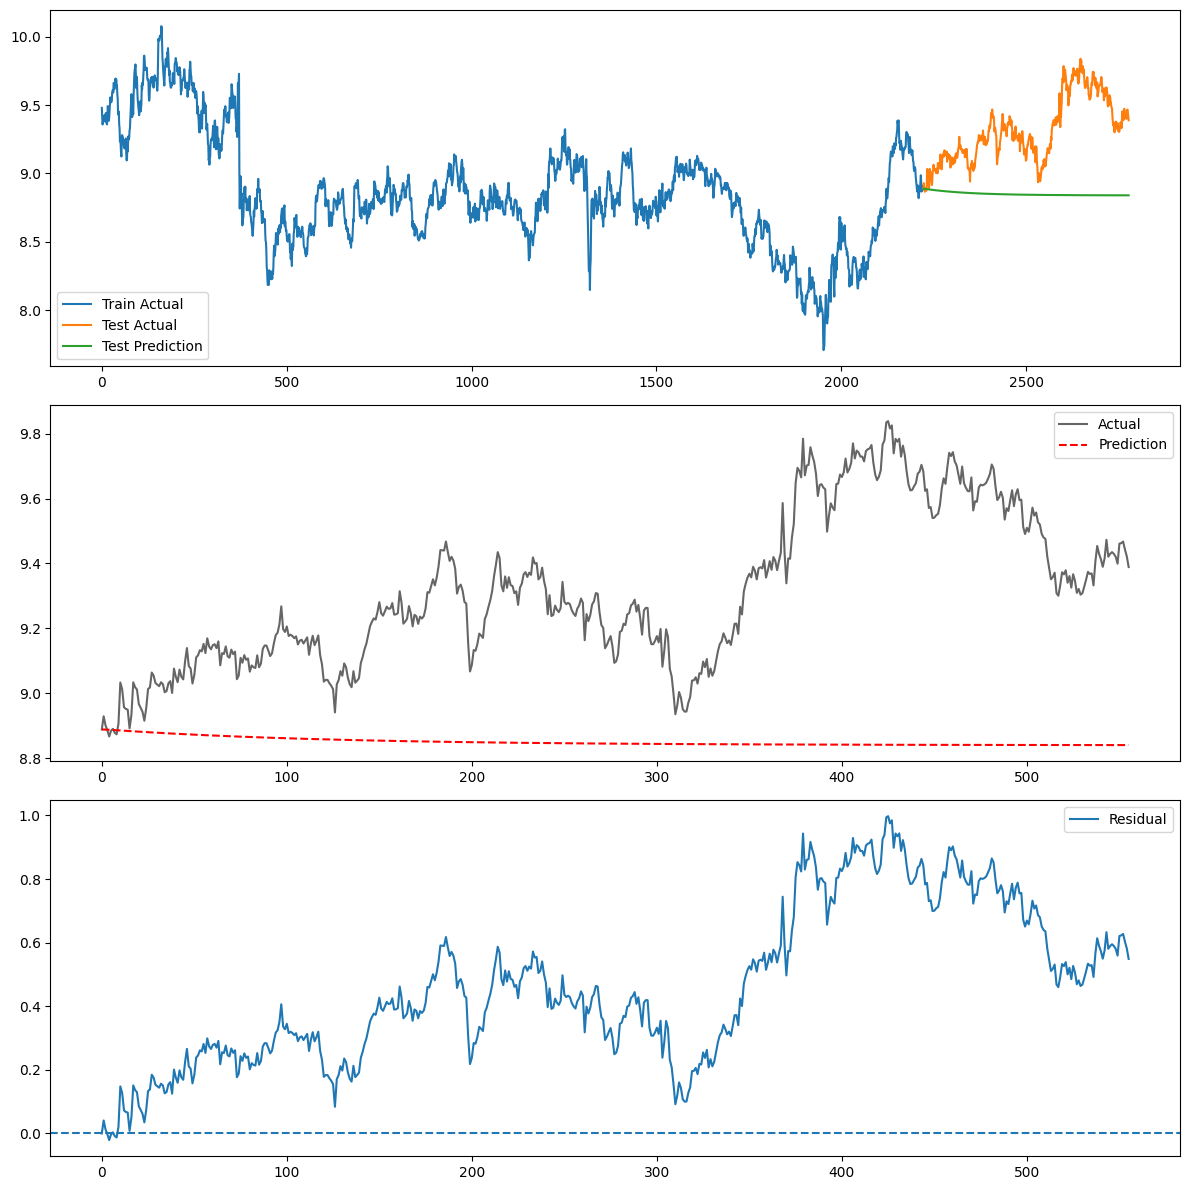


[ARX(level)] Deterministic metrics:
MSE: 0.331433
RMSE: 0.575702
MAE: 0.482571


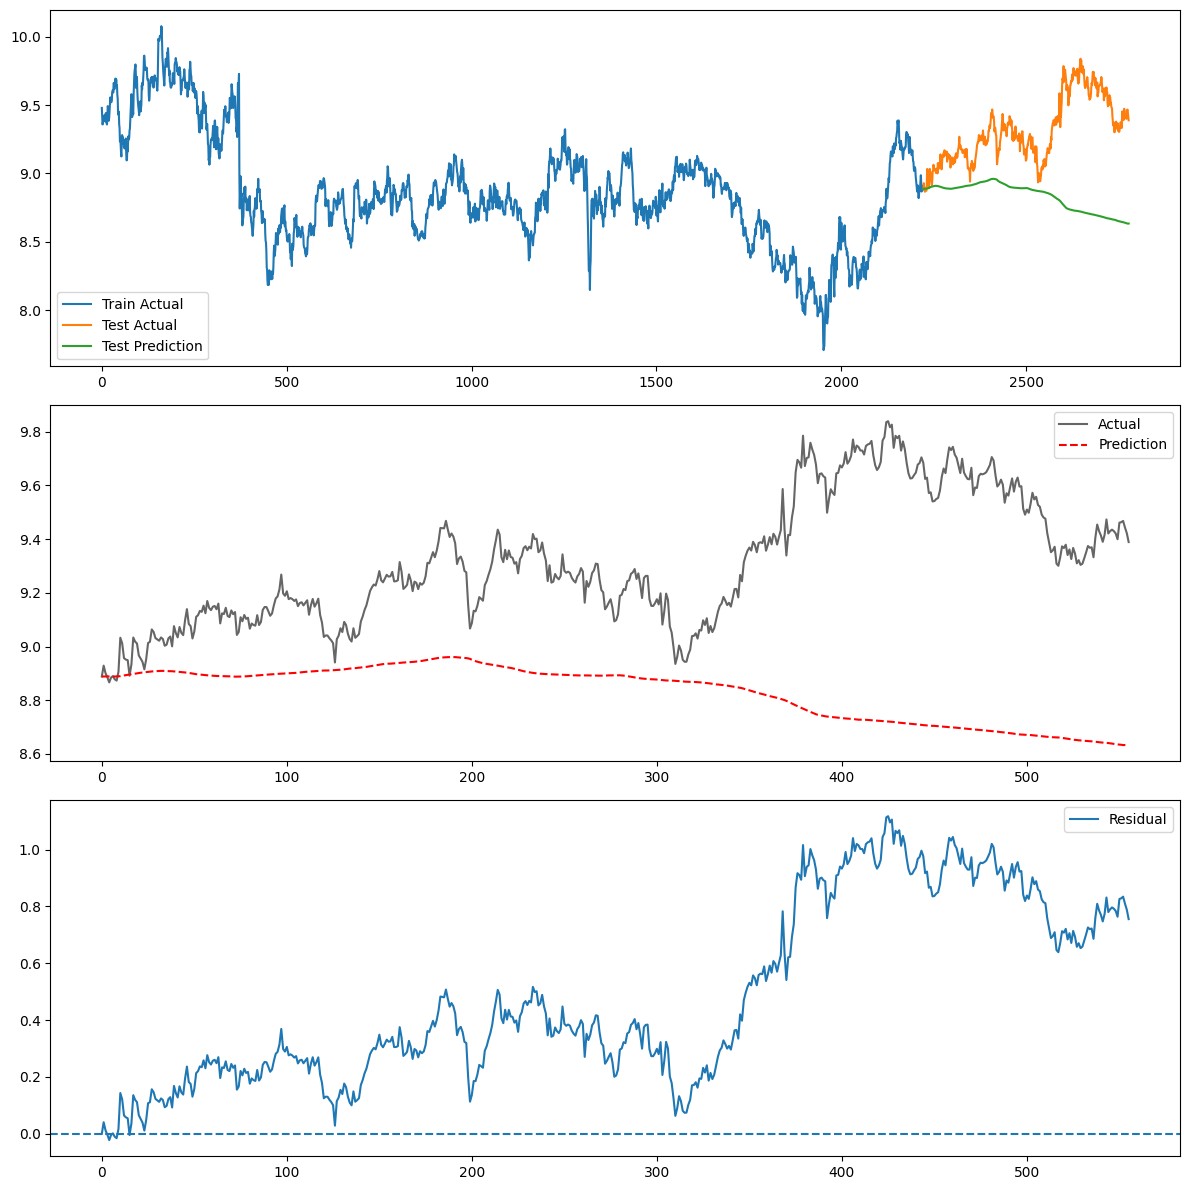

In [156]:
# --- Metrics + plots (aligned with LSTM deterministic) ---
ar_metrics = compute_metrics_lstm_style(pred_levels_ar, y_test_level)
print("\n[AR(level)] Deterministic metrics:")
for k,v in ar_metrics.items():
    print(f"{k}: {v:.6f}")

plot_predictions(preds=pred_levels_ar, targets=y_test_level, train_targets=y_train_level)

arx_metrics = compute_metrics_lstm_style(pred_levels_arx, y_test_level)
print("\n[ARX(level)] Deterministic metrics:")
for k,v in arx_metrics.items():
    print(f"{k}: {v:.6f}")

plot_predictions(preds=pred_levels_arx, targets=y_test_level, train_targets=y_train_level)